In [1]:
!!pip install keras tenserflow

['Requirement already satisfied: keras in /usr/local/lib/python3.12/dist-packages (3.13.2)',
 '\x1bERROR: Could not find a version that satisfies the requirement tenserflow (from versions: none)\x1b\x1b',
 '\x1b\x1bERROR: No matching distribution found for tenserflow\x1b\x1b',
 '\x1b']

In [2]:
# ── Imports ──
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {tf.keras.__version__}")

TensorFlow version : 2.19.0
Keras version      : 3.13.2


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ── Dataset Paths ──
TRAIN_DIR = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Train/"
TEST_DIR  = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Test/"

# Image dimensions (consistent shape as instructed)
IMG_HEIGHT = 28
IMG_WIDTH  = 28
NUM_CLASSES = 10

In [5]:
def load_images_from_folder(folder):
    """
    Loads images and labels from a folder structured as:
        folder/class_name/image_file

    Steps:
        1. Read each class sub-folder (sorted for consistency).
        2. Open each image with PIL, convert to grayscale.
        3. Resize to (IMG_HEIGHT, IMG_WIDTH).
        4. Normalize pixel values to [0, 1].
        5. Append image array and integer label.

    Returns:
        images (np.ndarray): shape (N, 28, 28)
        labels (np.ndarray): shape (N,)  — integer class indices
    """
    images = []
    labels = []

    # Sort class names so label indices are deterministic
    class_names = sorted(os.listdir(folder))
    class_map   = {name: idx for idx, name in enumerate(class_names)}

    print(f"Found {len(class_names)} classes in '{folder}': {class_names}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")                # grayscale
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))              # resize to 28×28
                img = np.array(img, dtype=np.float32) / 255.0         # normalize → [0,1]
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"  [WARNING] Could not load {img_path}: {e}")

    return np.array(images), np.array(labels)

In [6]:
# ── Load Training and Testing Datasets ──
x_train_raw, y_train_raw = load_images_from_folder(TRAIN_DIR)
x_test_raw,  y_test_raw  = load_images_from_folder(TEST_DIR)

print(f"\nRaw training set : {x_train_raw.shape}  |  Labels: {y_train_raw.shape}")
print(f"Raw testing set  : {x_test_raw.shape}   |  Labels: {y_test_raw.shape}")

Found 10 classes in '/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Train/': ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Found 10 classes in '/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Test/': ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']

Raw training set : (17000, 28, 28)  |  Labels: (17000,)
Raw testing set  : (3000, 28, 28)   |  Labels: (3000,)


In [7]:
# ── Flatten images for FCN input: (N, 28, 28) → (N, 784) ──
x_train = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)   # (N, 784)
x_test  = x_test_raw.reshape(-1,  IMG_HEIGHT * IMG_WIDTH)   # (N, 784)

# ── One-hot encode labels ──
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f"x_train shape : {x_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"x_test  shape : {x_test.shape}")
print(f"y_test  shape : {y_test.shape}")

x_train shape : (17000, 784)
y_train shape : (17000, 10)
x_test  shape : (3000, 784)
y_test  shape : (3000, 10)


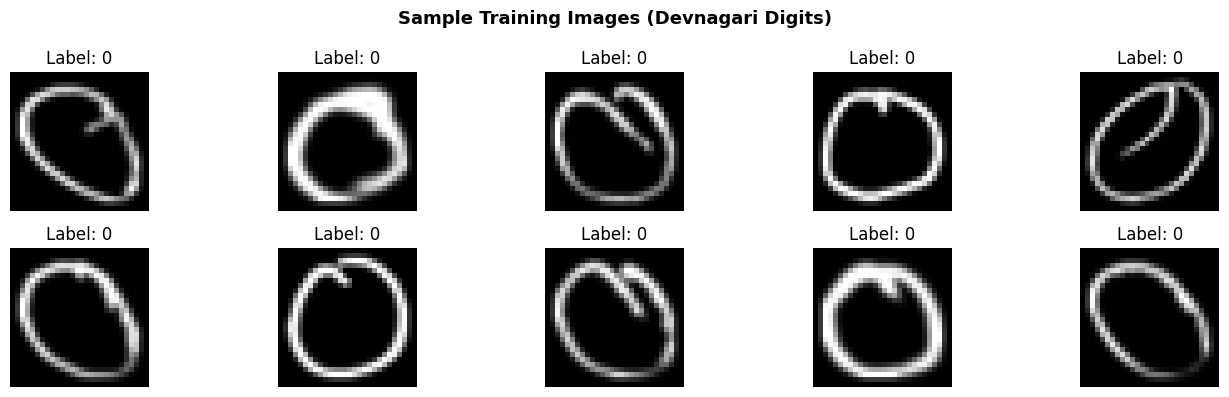

In [9]:
# ── Visualise sample images from the training set ──
plt.figure(figsize=(14, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_raw[i], cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.suptitle("Sample Training Images (Devnagari Digits)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 2: Build the FCN Model

Architecture (Sequential API):
- **Flatten** layer → converts 784-dim input
- **Hidden Layer 1:** 64 neurons, sigmoid activation
- **Hidden Layer 2:** 128 neurons, sigmoid activation
- **Hidden Layer 3:** 256 neurons, sigmoid activation
- **Output Layer:** 10 neurons, softmax activation

In [10]:
# ── Build the Sequential FCN Model ──
model = keras.Sequential(
    [
        keras.layers.Input(shape=(IMG_HEIGHT * IMG_WIDTH,)),   # 784-dim input

        # Hidden Layer 1
        keras.layers.Dense(64,  activation='sigmoid', name='hidden_1'),

        # Hidden Layer 2
        keras.layers.Dense(128, activation='sigmoid', name='hidden_2'),

        # Hidden Layer 3
        keras.layers.Dense(256, activation='sigmoid', name='hidden_3'),

        # Output Layer — 10 classes (Devnagari digits 0-9)
        keras.layers.Dense(NUM_CLASSES, activation='softmax', name='output'),
    ],
    name="FCN_Devnagari"
)

# Print model architecture summary
model.summary()

Model: "FCN_Devnagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

---
## Task 3: Compile the Model

- **Optimizer:** Adam
- **Loss Function:** Categorical Crossentropy (since labels are one-hot encoded)
- **Metric:** Accuracy

In [11]:
# ── Compile the Model ──
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"  Optimizer : Adam")
print(f"  Loss      : categorical_crossentropy")
print(f"  Metrics   : accuracy")

Model compiled successfully!
  Optimizer : Adam
  Loss      : categorical_crossentropy
  Metrics   : accuracy


---
## Task 4: Train the Model

- **Batch size:** 128
- **Epochs:** 20
- **Validation split:** 20%
- **Callbacks:** ModelCheckpoint + EarlyStopping

In [12]:
# ── Training Parameters ──
BATCH_SIZE       = 128
EPOCHS           = 20
VALIDATION_SPLIT = 0.2    # 20% of training data used for validation

# ── Callbacks ──
callbacks = [
    # Save the best model (lowest val_loss) during training
    keras.callbacks.ModelCheckpoint(
        filepath='best_devnagari_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    # Stop training early if val_loss doesn't improve for 5 consecutive epochs
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
]

print(f"Training config:")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Max epochs       : {EPOCHS}")
print(f"  Validation split : {int(VALIDATION_SPLIT * 100)}%")

Training config:
  Batch size       : 128
  Max epochs       : 20
  Validation split : 20%


In [13]:
# ── Train the Model ──
history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2628 - loss: 1.9735
Epoch 1: val_loss improved from None to 7.43648, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4567 - loss: 1.6334 - val_accuracy: 0.0000e+00 - val_loss: 7.4365
Epoch 2/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7977 - loss: 0.6494
Epoch 2: val_loss did not improve from 7.43648
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8159 - loss: 0.5278 - val_accuracy: 0.0000e+00 - val_loss: 8.9941
Epoch 3/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8717 - loss: 0.3350
Epoch 3: val_loss did not improve from 7.43648
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8971 - loss: 0.3035 - val_accuracy: 0.0000e+00 - val_loss: 9.7683
Epoch 4/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9357 - loss: 0.2222
Epoch 4: val_loss did not improve from 7.436

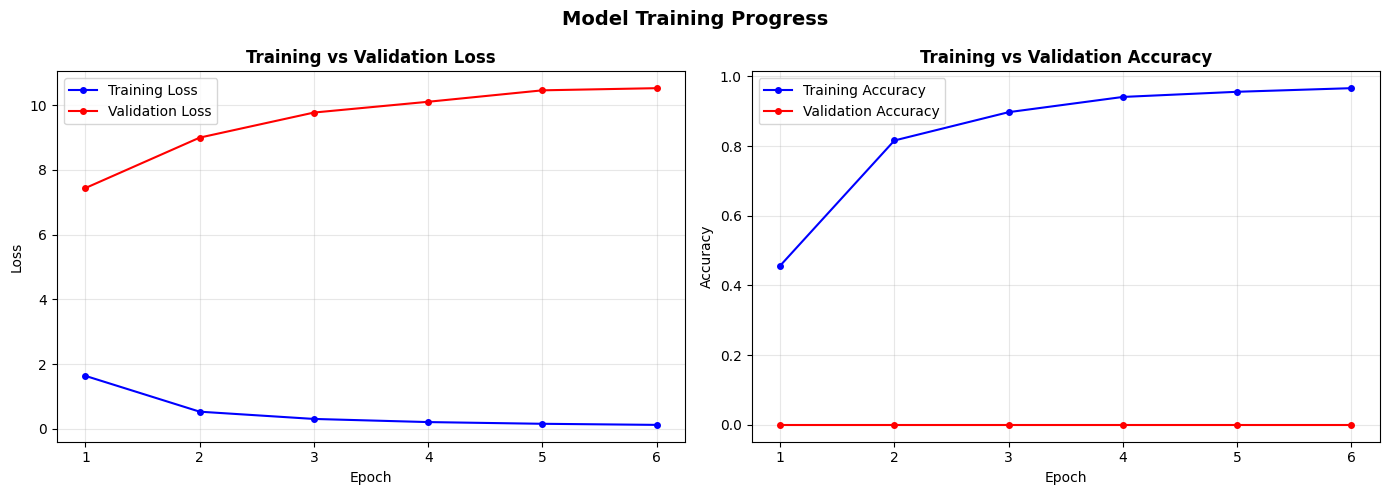

In [14]:
# ── Visualise Training Progress ──
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
epochs_ran = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs_ran, train_loss, 'b-o', markersize=4, label='Training Loss')
plt.plot(epochs_ran, val_loss,   'r-o', markersize=4, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs_ran, train_acc, 'b-o', markersize=4, label='Training Accuracy')
plt.plot(epochs_ran, val_acc,   'r-o', markersize=4, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('Model Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 5: Evaluate the Model

Evaluate the trained model on the **test set** to check final accuracy and loss.

In [15]:
# ── Evaluate on Test Set ──
print("Evaluating model on test set...\n")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"\n{'='*40}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc * 100:.2f}%)")
print(f"{'='*40}")

Evaluating model on test set...

94/94 - 0s - 3ms/step - accuracy: 0.6033 - loss: 2.1531

  Test Loss     : 2.1531
  Test Accuracy : 0.6033  (60.33%)


---
## Task 6: Save and Load the Model

Save the trained model to a `.h5` file, then reload it and re-evaluate.

In [16]:
# ── Save the Model ──
MODEL_PATH = 'devnagari_fcn_model.h5'
model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

Model saved to: devnagari_fcn_model.h5


In [17]:
# ── Load the Saved Model ──
loaded_model = tf.keras.models.load_model(MODEL_PATH)
print(f"Model loaded from: {MODEL_PATH}")
loaded_model.summary()

Model loaded from: devnagari_fcn_model.h5


Model: "FCN_Devnagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,156 (367.80 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [18]:
# ── Re-evaluate the Loaded Model ──
print("Re-evaluating the loaded model on test set...\n")
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)

print(f"\n{'='*40}")
print(f"  Loaded Model Test Loss     : {loaded_loss:.4f}")
print(f"  Loaded Model Test Accuracy : {loaded_acc:.4f}  ({loaded_acc * 100:.2f}%)")
print(f"{'='*40}")

Re-evaluating the loaded model on test set...

94/94 - 1s - 8ms/step - accuracy: 0.6033 - loss: 2.1531

  Loaded Model Test Loss     : 2.1531
  Loaded Model Test Accuracy : 0.6033  (60.33%)


---
## Task 7: Making Predictions

Use `model.predict()` on the test set, convert probability outputs to digit labels using `np.argmax()`, and visualise results.

In [19]:
# ── Make Predictions ──
print("Generating predictions on test set...")
predictions = loaded_model.predict(x_test, verbose=0)

# Convert predicted probability distributions to class labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test,      axis=1)

print(f"Predictions shape : {predictions.shape}")
print(f"\nFirst 10 Predicted Labels : {predicted_labels[:10]}")
print(f"First 10 True Labels      : {true_labels[:10]}")

Generating predictions on test set...
Predictions shape : (3000, 10)

First 10 Predicted Labels : [0 0 0 0 0 7 0 0 0 0]
First 10 True Labels      : [0 0 0 0 0 0 0 0 0 0]


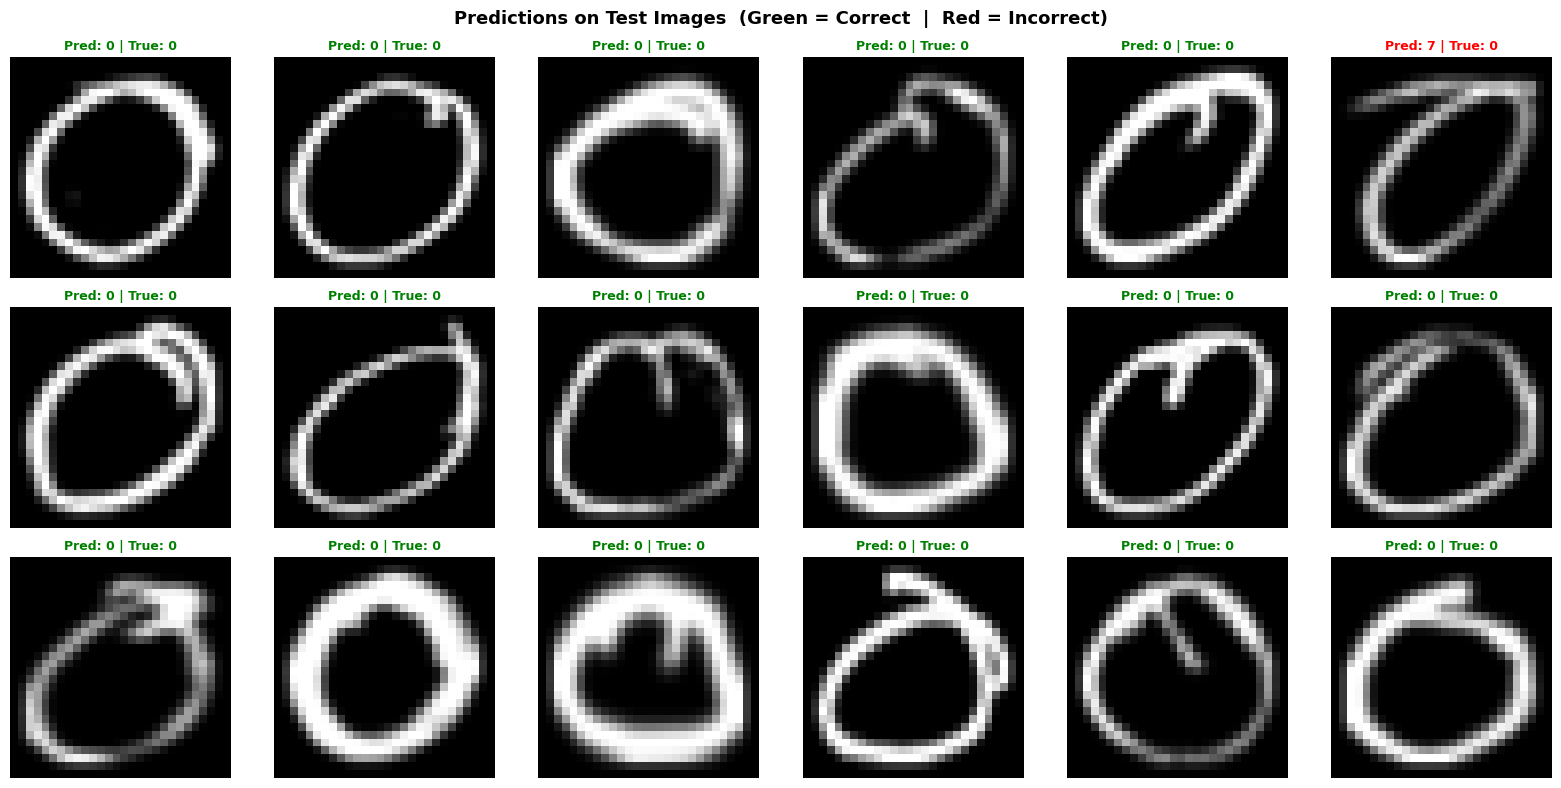

In [20]:
# ── Visualise Predictions — Correct vs Incorrect ──
fig, axes = plt.subplots(3, 6, figsize=(16, 8))
axes = axes.flatten()

for i in range(18):
    img   = x_test_raw[i]
    pred  = predicted_labels[i]
    true  = true_labels[i]
    color = 'green' if pred == true else 'red'

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(
        f"Pred: {pred} | True: {true}",
        color=color, fontsize=9, fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle(
    'Predictions on Test Images  (Green = Correct  |  Red = Incorrect)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [21]:
# ── Per-class Accuracy Breakdown ──
print("Per-class Accuracy:\n")
print(f"{'Class':<10} {'Correct':>10} {'Total':>10} {'Accuracy':>12}")
print("-" * 46)

for cls in range(NUM_CLASSES):
    mask    = (true_labels == cls)
    correct = np.sum(predicted_labels[mask] == cls)
    total   = np.sum(mask)
    acc     = correct / total if total > 0 else 0
    print(f"digit_{cls:<4}  {correct:>10}  {total:>10}  {acc * 100:>10.2f}%")

print("-" * 46)
overall = np.sum(predicted_labels == true_labels) / len(true_labels)
print(f"{'Overall':<10} {np.sum(predicted_labels == true_labels):>10}  {len(true_labels):>10}  {overall * 100:>10.2f}%")

Per-class Accuracy:

Class         Correct      Total     Accuracy
----------------------------------------------
digit_0            291         300       97.00%
digit_1            294         300       98.00%
digit_2            275         300       91.67%
digit_3             21         300        7.00%
digit_4            290         300       96.67%
digit_5            204         300       68.00%
digit_6            190         300       63.33%
digit_7            245         300       81.67%
digit_8              0         300        0.00%
digit_9              0         300        0.00%
----------------------------------------------
Overall          1810        3000       60.33%


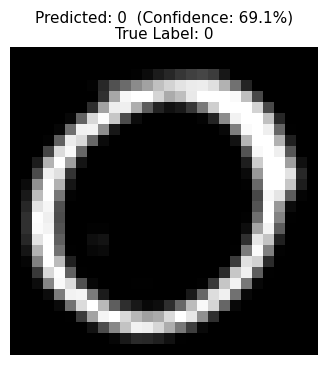

Predicted label : 0
True label      : 0
Confidence      : 69.14%


In [22]:
# ── Single Image Prediction Demo ──
sample_idx = 0
sample_img = x_test[sample_idx].reshape(1, -1)   # shape (1, 784)

single_pred  = loaded_model.predict(sample_img, verbose=0)
pred_label   = np.argmax(single_pred)
true_label   = true_labels[sample_idx]
confidence   = np.max(single_pred) * 100

plt.figure(figsize=(4, 4))
plt.imshow(x_test_raw[sample_idx], cmap='gray')
plt.title(
    f"Predicted: {pred_label}  (Confidence: {confidence:.1f}%)\nTrue Label: {true_label}",
    fontsize=11
)
plt.axis('off')
plt.show()

print(f"Predicted label : {pred_label}")
print(f"True label      : {true_label}")
print(f"Confidence      : {confidence:.2f}%")

Summary

In this project, we successfully completed all the required tasks for building and evaluating a model using the Devanagari dataset.

* First, we loaded and preprocessed the Devanagari dataset using the PIL library. The images were prepared properly so they could be used as input for the model.

* Next, we built a Sequential Fully Connected Network (FCN) with multiple layers. The architecture included layers of sizes 64, 128, 256, and finally an output layer with 10 neurons for classification.

* After building the model, we compiled it using the Adam optimizer, categorical cross-entropy as the loss function, and accuracy as the evaluation metric.

* We then trained the model using a batch size of 128 and ran it for 20 epochs. A validation split of 0.2 was used to monitor performance during training, and callbacks were applied to improve training efficiency.

* Once training was complete, we evaluated the model on the test dataset to measure its performance.

* After evaluation, we saved the trained model in .h5 format and later reloaded it to ensure it could be reused without retraining.

Finally, we made predictions using the model. The predicted outputs were converted into class labels using np.argmax(), and the results were visualized for better understanding.